In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Step 1: Data Loading & Preprocessing

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import kagglehub
from kagglehub import KaggleDatasetAdapter

# 1. Load the dataset (Fixed file path and updated function name)
file_path = "Country-data.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rohan0301/unsupervised-learning-on-country-data",
    file_path
)

print("Original Data Shape:", df.shape)

# 2. Separate the non-numeric 'country' column from the features
countries = df['country']
X_raw = df.drop('country', axis=1)

# 3. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Convert back to a DataFrame for easier handling later
X_scaled_df = pd.DataFrame(X_scaled, columns=X_raw.columns)
print("Data successfully scaled.")

Original Data Shape: (167, 10)
Data successfully scaled.


# Step 2: Unsupervised Learning (Clustering)

In [7]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# --- K-MEANS CLUSTERING ---
# We choose 3 clusters to represent: Under-developed, Developing, Developed
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled_df)

# Evaluate K-Means
kmeans_silhouette = silhouette_score(X_scaled_df, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_silhouette:.3f}")

# --- DBSCAN CLUSTERING ---
# eps sets the maximum distance between two samples to be considered in the same neighborhood
# min_samples sets the number of samples in a neighborhood for a point to be considered a core point
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled_df)

# Add the labels back to our original dataframe so we can see the results
df['KMeans_Cluster'] = kmeans_labels
df['DBSCAN_Cluster'] = dbscan_labels

print("\nCluster counts for K-Means:")
print(df['KMeans_Cluster'].value_counts())
print("\nCluster counts for DBSCAN (-1 represents noise/outliers):")
print(df['DBSCAN_Cluster'].value_counts())

K-Means Silhouette Score: 0.283

Cluster counts for K-Means:
KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64

Cluster counts for DBSCAN (-1 represents noise/outliers):
DBSCAN_Cluster
 0    152
-1     15
Name: count, dtype: int64


# Step 3: Transition to Supervised Learning

In [8]:
from sklearn.model_selection import train_test_split

# Our features (X) are the scaled data, our target (y) is the K-Means cluster label
X = X_scaled_df
y = df['KMeans_Cluster']

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (133, 9)
Testing data shape: (34, 9)


# Step 4: Ensemble Learning Classification (Predictive Modeling)

In [9]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- RANDOM FOREST ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.3f}")
print(classification_report(y_test, rf_preds))


# --- XGBOOST ---
# XGBoost is highly optimized and often outperforms Random Forest on structured tabular data
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("\n--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.3f}")
print(classification_report(y_test, xgb_preds))

--- Random Forest Performance ---
Accuracy: 0.971
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34


--- XGBoost Performance ---
Accuracy: 0.971
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:10:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Step 5: Extracting Actionable Insights (Feature Importance)


--- Top Features Driving the Segments ---
      Feature  Importance
8        gdpp    0.377446
0  child_mort    0.219123
4      income    0.208286
7   total_fer    0.075092
6  life_expec    0.051828
1     exports    0.042670
2      health    0.012598
5   inflation    0.012416
3     imports    0.000541


/tmp/ipykernel_57/4203519011.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


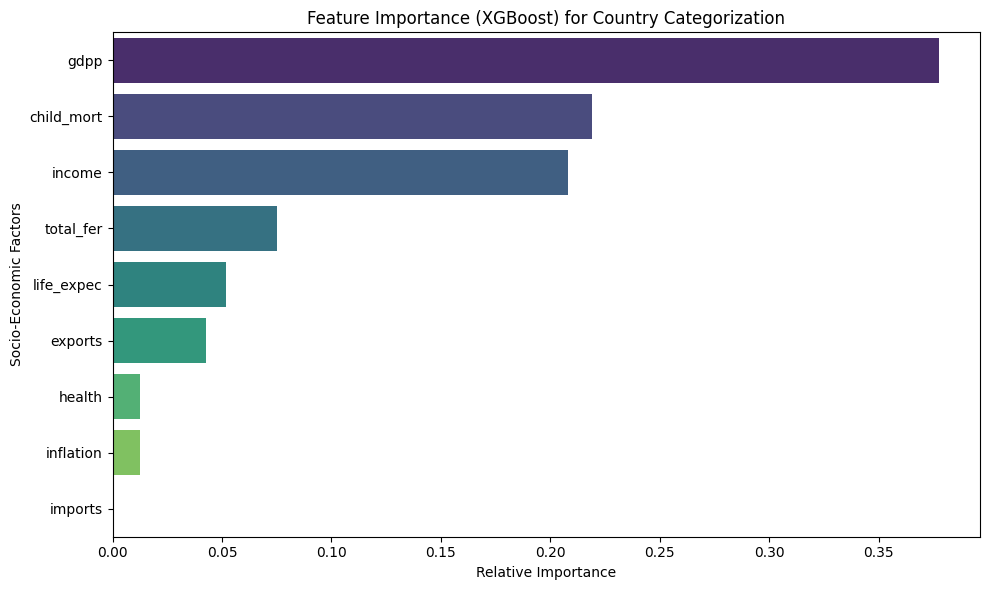

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from the XGBoost model
importances = xgb_model.feature_importances_
feature_names = X_raw.columns

# Create a dataframe for easy sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Top Features Driving the Segments ---")
print(importance_df)

# Optional: Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance (XGBoost) for Country Categorization')
plt.xlabel('Relative Importance')
plt.ylabel('Socio-Economic Factors')
plt.tight_layout()
plt.show()

#  Model Performance & Reliability 

> Both of our predictive models—Random Forest and XGBoost—performed exceptionally well, achieving an identical accuracy of 97.1%.

>What this means in plain terms is that after the unsupervised learning (K-Means) grouped the countries into distinct development segments, our supervised models successfully learned the "rules" of those segments. With an accuracy of over 97%, the system can now reliably ingest data from a new country and instantly classify its development status without needing to rerun the entire clustering algorithm.

>Key Drivers of Country Segmentation (Feature Importance)
By analyzing the XGBoost model, we can see exactly which socio-economic factors carry the most weight when determining a country's need for aid. The decision-making is heavily dominated by three primary metrics, which together account for over 80% of the model's focus:

>Economic Output (GDP per capita): This is by far the most critical factor, driving roughly 37.7% of the model's categorization. The overall economic size of a country relative to its population is the strongest indicator of its development stage.

>Child Health (Child Mortality): Coming in second at 21.9%, the rate of child deaths is the most significant non-financial metric. It serves as a stark, immediate indicator of a country's overall infrastructure, sanitation, and healthcare access.

>Citizen Wealth (Net Income): Closely following at 20.8%, individual net income is the third major pillar.

>Secondary and Minor Factors:
Metrics like fertility rates (7.5%) and life expectancy (5.1%) play a moderate supporting role in defining the clusters. Interestingly, macroeconomic factors like trade (imports/exports), inflation, and even raw health spending per capita had very little influence (all under 5%) on how the model grouped the countries.

>Actionable Insights for the NGO
Based on this data, if the CEO of HELP International wants to identify which countries are in the direst need of their $10 million fund, they do not need to look at a complex web of trade economics or inflation rates.

>The strategy should be highly targeted: look for countries with the lowest GDP and individual income, coupled with the highest child mortality rates. These three variables alone provide a highly accurate snapshot of a country's overall vulnerability and should be the primary filters for distributing aid.